# Treatment of Experimental Data
<div>
  <center> <img height="500" src="https://github.com/prajay-patel/CHE-3131/blob/main/Rotation-1-Treatment-of-Data/Figures/MonteCarlo.png?raw=True"> </center>
</div>


<a target="_blank" href="https://colab.research.google.com/github/prajay-patel/CHE-3131/blob/main/Rotation-1-Treatment-of-Data/Treatment_of_Experimental_Data.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [ ]:
# @title Overview
%%html
<style>
div.info {
    color: #0056b3;
    background-color: #d9edf7;
    border-left: 5px solid #31708f;
    padding: 0.5em;
    font-size: 1.25em; /* A little larger the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.info ul {
    margin: 0.5em 0; /* Space around the list */
}
div.info li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="info">
    <strong>Questions:</strong>
    <ul>
        <li>How can you import your data from Excel into Python?</li>
        <li>How do I choose and create the correct plot?</li>
        <li>What are different ways to represent experimental uncertainty?</li>
        <li>What is the extent of data needed for proper calibration?</li>
    </ul>

    <strong>Objectives:</strong>
    <ul>
        <li>Open your data and compute a linear regression.</li>
        <li>Use various matplotlib plot types to visualize uncertainty.</li>
    </ul>
</div>

## Import Packages

In [4]:
# @title Import standard packages (expand for more details)
%%capture
import numpy as np

# Import plotting functions and customizing the font for plots
import matplotlib
import matplotlib.pyplot as plt

# Changes the default font size for all plots
matplotlib.rcParams.update({'font.size': 16})

# If you want to customize font size and family of your plots by default,
# uncomment the next three lines and change settings accordingly

#matplotlib.rcParams.update({'font.size': 20})
#matplotlib.rcParams.update({'font.family': 'Arial'})
#matplotlib.rcParams.update({'mathtext.fontset' : 'custom'})

# Import scipy packages for linear regression
# Using asterisks is a way to import everything
import scipy
from scipy import stats
from scipy.stats import *

# Import the pandas dataframe package for Excel-like analysis
import pandas as pd

# Insert a progress bar to show the progress of the script
# This is helpful for things that will take a while
!pip install tqdm
!jupyter nbextension enable --py widgetsnbextension
from tqdm.notebook import tqdm, tnrange, trange

In [5]:
# @title Import Quiz Packages (only hit the play button once)
%%capture
%pip install "jupyterquiz"
from jupyterquiz import display_quiz

#Import quizzes and rotation1.json from GitHub
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-1-Treatment-of-Data/rotation1.json
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-1-Treatment-of-Data/Sample-Data/Lab1_SampleData_Calibration.xlsx
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-1-Treatment-of-Data/Sample-Data/Lab1_SampleData_Option1.xlsx
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-1-Treatment-of-Data/Sample-Data/Lab1_SampleData_Option2.xlsx
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-1-Treatment-of-Data/Sample-Data/MonteCarlo_SampleData.xlsx
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/quiz_utils.py

import quiz_utils

In [ ]:
# @title Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Part 1. Introductory Data Analysis in Python


## 1.1 Pandas DataFrames
DataFrames work in 2 dimensions where you can do operations on each column and/or row.

This is denoted by **assigning a variable** to a DataFrame (e.g., df) and then the operation (mean, std, sum, etc.). For example,
```python
df = pd.read_excel(...)
df.mean()
```
In the parentheses part of the operation, there are two main options.

```python
axis=0 # Operations along the column
axis=1 # Operations along the row
```

In [ ]:
# @title Exercise: axis=0 vs. axis=1
%%html
<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
    <p>Calculate the mean and standard deviation by doing the following:
    <ul>
      <li>Import the sample data for Option 2 using <code>pd.read_excel()</code>
      to a variable named sample_data</li>
      <li>Calculate the mean using the mean function (<code>sample_data.mean()</code>).</li>
      <ul>
        <li> Use the <code>axis=0</code> and <code>axis=1</code> options (<code>sample_data.mean(axis=0)</code>)
      </ul>
    <li> Use the standard deviation function (<code>sample_data.std()</code>)</li>
    </ul>
    </p>
</div>

In [ ]:
# Import the sample data here
sample_data=pd.read_excel('Lab1_SampleData_Option2.xlsx',sheet_name='Trial 1',index_col='time')
sample_data

,20,19,18,17,16,15,14,13,12,11,10
time,,,,,,,,,,,
0,100.161,105.609,110.452,117.111,123.467,130.732,139.207,148.892,160.394,172.804,187.938
1,100.161,105.609,110.755,117.111,123.467,130.732,139.207,148.892,160.394,173.107,187.938
2,99.858,105.609,110.755,117.111,123.467,130.732,139.207,148.590,160.091,172.501,187.938
3,100.161,105.609,110.452,116.808,123.770,130.732,139.207,148.590,160.697,173.409,187.938
4,100.161,105.609,110.452,117.111,123.467,130.429,139.207,148.892,160.697,173.409,187.938
5,100.161,105.609,111.057,117.111,123.467,130.732,138.904,148.892,160.697,173.107,187.635
6,100.464,105.306,110.755,116.808,123.467,130.732,139.207,148.590,160.697,172.804,187.938
7,100.161,105.306,110.755,117.111,123.467,130.732,139.207,148.892,160.394,173.107,187.938
8,100.161,105.912,110.452,117.111,123.467,130.732,139.509,148.892,160.697,173.107,187.938


In [ ]:
# Calculate the mean of sample_data along axis 0
sample_data.mean(axis=0)

,0
20,100.190686
19,105.496137
18,110.648000
17,117.027843
16,123.502647
15,130.642804
14,139.230549
13,148.779510
12,160.554333
11,172.946529


In [ ]:
# Calculate the mean of sample_data along axis 1
sample_data.mean(axis=1).head(10)

,0
time,
0,136.069727
1,136.124818
2,135.987182
3,136.124818
4,136.124727
5,136.124727
6,136.069818
7,136.097273
8,136.179818


In [ ]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation1.json',"lab-1-1")

<IPython.core.display.Javascript object>

In [ ]:
# @title Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
  <p>Use <b><code>ddof=1</code></b> to match the sample standard deviation calculated in Excel.
    By default, Python computes the standard deviation of the population (<code>ddof=0</code>).
  </p>
</div>

In [ ]:
# Calculate the standard deviation of sample_data here using the chosen axis (0 or 1)
sample_data.std(ddof=1,axis=0)

,0
20,0.184294
19,0.181349
18,0.199245
17,0.192330
16,0.115729
15,0.194271
14,0.199211
13,0.159407
12,0.212822
11,0.204050


## 1.2 t-test function

Define the two-tailed t-test function.

Run this function once and you will be able to calculate the t-test value at any point afterwards by typing in ```tinv(p,df)```

You can also just change the value here and keep it constant for the rest of the notebook.



In [10]:
def tinv(p, df):
  '''
  A Python function that computes the two-tailed student's t value
  p = probability (5% or 0.05)
  df = degrees of freedom
  '''
  return np.abs(t.ppf(p/2, df))

tValue = tinv(0.05, 51)
tValue

np.float64(2.007583770315836)

## 1.3 Plotting $\Delta_{95\%}p$


In [3]:
# @title Exercise: Redo the pre-lab
%%html
<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
    <p>Recreate the plot you chose best represents the sample data in the pre-lab with <b>your data</b> measuring the pressure sensor
      for 100 seconds:
    <ul>
      <li>Import your data using <code>pd.read_excel()</code> to a variable called sensor_data</li>
      <li>Create the plot of the type you chose as the most representative using the same code you used for the pre-lab</li>
      <li>Use the <code>tinv</code> function to calculate the student t value with the correct number of DOF</li>
      <li>Hide the tick marks on the x axis using <code>plt.xticks([])</code></li>
    </ul>
    </p>
</div>

In [ ]:
sensor_data=pd.read_excel('Lab1_SampleData_Calibration.xlsx',sheet_name='Calibration',index_col='time')

#Calculated via Python
ts2=tinv(0.05,100)
avg=sensor_data.mean()
stdev=sensor_data.std(ddof=1)

# Variables defining upper and lower limits
# Students can use Excel to calculate these values and then place their answers here
upper=avg+ts2*stdev
lower=avg-ts2*stdev

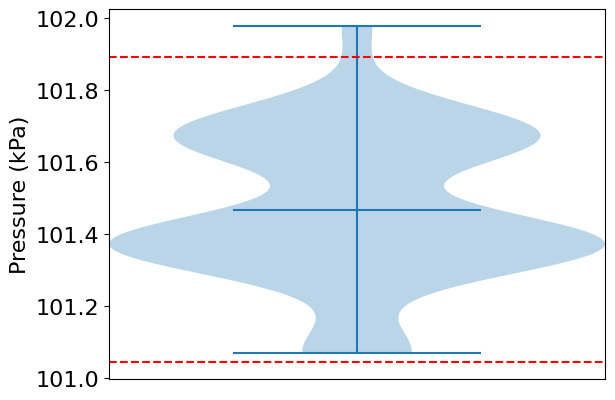

In [ ]:
# Create a violin plot of the data you just imported
# showmeans=True is an optional keywords students can include
plt.violinplot(sensor_data,showmeans=True)
plt.ylabel('Pressure (kPa)')
plt.xticks([])
plt.hlines(upper,0.75,1.25,color='r',linestyles='dashed')
plt.hlines(lower,0.75,1.25,color='r',linestyles='dashed')
plt.xlim(0.75,1.25) #Optional for display
plt.show()

## 1.4 Mean and standard deviation

In [ ]:
# @title Concept Check
quiz_utils.json_to_quiz('rotation1.json',"lab-1-2")

<IPython.core.display.Javascript object>

In [ ]:
# @title Exercise: Import and prepare your data for analysis
%%html
<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
    <p>There were two options on how you collected your data.
      Based on what your group selected, follow the instructions for the specific spreadsheet option to calculate the mean and
      standard deviation of your pressure measurements.
    </p>
</div>

In [2]:
# @title # **STOP HERE**
%%html
<style>
div.red-alert {
    color: #64312E; /* Darker shade of orange for text */
    background-color: #EED7D7; /* Light orange background */
    border-left: 5px solid #A41E22; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.red-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.red-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="red-alert">
  <strong>WAIT</strong>
  <p> Given how the sample data looks, reformat your Excel workbook so that it follows the formatting of
    the sample data. Otherwise, you may spend more time debugging than you would like when dealing with Pandas.
  </p>
</div>

#### Spreadsheet Option 1 (3 measurements)
If your Excel sheet names follow
<center>
<font size="+1">20, 19, 18, 17, 16, 15, ...
</center>

Then expand this section and do the following exercise.

* Define a variable for each volume

```python
p20=pd.read_excel('file.xlsx',sheet_name='')
p19=...
```

* You can choose the name of the variables used to define each volume, but it has to start with a letter.

* Alternatively, you can use ```sheet_name=None``` to import all the sheets at once. You will then be using the dictionary data type to sort through your data.

In [ ]:
# @title Exercise: Determining $\mu\pm\sigma$
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
    <p>Calculate the mean and standard deviation of all your data</p>
    <ul>
    <li>Import each volume measurement by using <code>pd.read_excel</code></li>
    <ul>
    <li>You will need quotes for the text of the sheet name to match your sheet name</li>
    </ul>
    <li>Calculate the mean for each volume along the appropriate axis</li>
    <li>Calculate the standard deviation for each volume</li>
    <li>Compute the 95% confidence interval by using the appropriate t value</li>
    <li>Calculate the inverse pressure (<code>inv_p</code>) as the inverse of the mean of the three pressure arrays</li>
    <ul><li>Your answer here will an array with 11 elements, one for each volume</li></ul>
    <li>Calculate the error of inverse pressure (<code>inv_p_95CI</code>):
    \( \Delta\bigg(\dfrac{1}{p}\bigg) = \dfrac{\Delta_{95\%}p}{p^2}\)</li>
    <ul><li>Let \(\Delta_{95\%}p\) be the mean of the 95% confidence intervals of all trials for simplicity</li></ul>
    </ul>
</div>

In [ ]:
# @title Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
  <p>Multi line cursor mode allow one to edit multiple lines of text at the same time.
    Use this to help save time when editing repeating blocks of code.
  </p>
    <ul>
        <li>Windows: <b>Alt+Shift (hold)</b> </li>
        <li>Mac: <b>Option+Shift (hold)</b> </li>
    </ul>
</div>


In [ ]:
# Import each volume measurement by using pd.read_excel
p20=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='20',index_col='time')
p19=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='19',index_col='time')
p18=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='18',index_col='time')
p17=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='17',index_col='time')
p16=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='16',index_col='time')
p15=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='15',index_col='time')
p14=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='14',index_col='time')
p13=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='13',index_col='time')
p12=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='12',index_col='time')
p11=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='11',index_col='time')
p10=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name='10',index_col='time')

# To import all sheets at once (imports as Python dictionary)
p_data=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name=None,index_col='time')

In [ ]:
# Calculate the mean pressure for each volume along the appropriate axis.
# This should give you three values per volume (trial 1, trial 2, trial 3)
p20_mean=p20.mean(axis=0)
p19_mean=p19.mean(axis=0)
p18_mean=p18.mean(axis=0)
p17_mean=p17.mean(axis=0)
p16_mean=p16.mean(axis=0)
p15_mean=p15.mean(axis=0)
p14_mean=p14.mean(axis=0)
p13_mean=p13.mean(axis=0)
p12_mean=p12.mean(axis=0)
p11_mean=p11.mean(axis=0)
p10_mean=p10.mean(axis=0)

# To calculate the mean for each pressure using the dictionary
# This will be the same result as above
p20_mean_dict=p_data['20'].mean()
p19_mean_dict=p_data['19'].mean()
p18_mean_dict=p_data['18'].mean()
p17_mean_dict=p_data['17'].mean()
p16_mean_dict=p_data['16'].mean()
p15_mean_dict=p_data['15'].mean()
p14_mean_dict=p_data['14'].mean()
p13_mean_dict=p_data['13'].mean()
p12_mean_dict=p_data['12'].mean()
p11_mean_dict=p_data['11'].mean()
p10_mean_dict=p_data['10'].mean()

In [ ]:
# Check the value of your pressures at 20 cm^-1 to make sure you did this correctly
p20_mean, p20_mean_dict

(Trial 1    100.190686
 Trial 2    101.342078
 Trial 3    101.247216
 dtype: float64,
 Trial 1    100.190686
 Trial 2    101.342078
 Trial 3    101.247216
 dtype: float64)

In [ ]:
# Calculate the standard deviation for each volume
# This should give you three values per volume (trial 1, trial 2, trial 3)

p20_std=p20.std(axis=0,ddof=1)
p19_std=p19.std(axis=0,ddof=1)
p18_std=p18.std(axis=0,ddof=1)
p17_std=p17.std(axis=0,ddof=1)
p16_std=p16.std(axis=0,ddof=1)
p15_std=p15.std(axis=0,ddof=1)
p14_std=p14.std(axis=0,ddof=1)
p13_std=p13.std(axis=0,ddof=1)
p12_std=p12.std(axis=0,ddof=1)
p11_std=p11.std(axis=0,ddof=1)
p10_std=p10.std(axis=0,ddof=1)

# To calculate the mean for each pressure using the dictionary
# This will be the same result as above
p20_std_dict=p_data['20'].std(axis=0,ddof=1)
p19_std_dict=p_data['19'].std(axis=0,ddof=1)
p18_std_dict=p_data['18'].std(axis=0,ddof=1)
p17_std_dict=p_data['17'].std(axis=0,ddof=1)
p16_std_dict=p_data['16'].std(axis=0,ddof=1)
p15_std_dict=p_data['15'].std(axis=0,ddof=1)
p14_std_dict=p_data['14'].std(axis=0,ddof=1)
p13_std_dict=p_data['13'].std(axis=0,ddof=1)
p12_std_dict=p_data['12'].std(axis=0,ddof=1)
p11_std_dict=p_data['11'].std(axis=0,ddof=1)
p10_std_dict=p_data['10'].std(axis=0,ddof=1)

In [ ]:
# Compute the 95% confidence interval by using the appropriate t value
p20_95CI=p20_std*tValue
p19_95CI=p19_std*tValue
p18_95CI=p18_std*tValue
p17_95CI=p17_std*tValue
p16_95CI=p16_std*tValue
p15_95CI=p15_std*tValue
p14_95CI=p14_std*tValue
p13_95CI=p13_std*tValue
p12_95CI=p12_std*tValue
p11_95CI=p11_std*tValue
p10_95CI=p10_std*tValue

# To calculate the mean for each pressure using the dictionary
# This will be the same result as above
p20_95CI_dict=p20_std_dict*tValue
p19_95CI_dict=p19_std_dict*tValue
p18_95CI_dict=p18_std_dict*tValue
p17_95CI_dict=p17_std_dict*tValue
p16_95CI_dict=p16_std_dict*tValue
p15_95CI_dict=p15_std_dict*tValue
p14_95CI_dict=p14_std_dict*tValue
p13_95CI_dict=p13_std_dict*tValue
p12_95CI_dict=p12_std_dict*tValue
p11_95CI_dict=p11_std_dict*tValue
p10_95CI_dict=p10_std_dict*tValue

In [ ]:
# Calculate the average of averages for pressure and the 95% CI

p20_mean=p20_mean.mean(axis=0)
p19_mean=p19_mean.mean(axis=0)
p18_mean=p18_mean.mean(axis=0)
p17_mean=p17_mean.mean(axis=0)
p16_mean=p16_mean.mean(axis=0)
p15_mean=p15_mean.mean(axis=0)
p14_mean=p14_mean.mean(axis=0)
p13_mean=p13_mean.mean(axis=0)
p12_mean=p12_mean.mean(axis=0)
p11_mean=p11_mean.mean(axis=0)
p10_mean=p10_mean.mean(axis=0)

p20_95CI=p20_95CI.mean(axis=0)
p19_95CI=p19_95CI.mean(axis=0)
p18_95CI=p18_95CI.mean(axis=0)
p17_95CI=p17_95CI.mean(axis=0)
p16_95CI=p16_95CI.mean(axis=0)
p15_95CI=p15_95CI.mean(axis=0)
p14_95CI=p14_95CI.mean(axis=0)
p13_95CI=p13_95CI.mean(axis=0)
p12_95CI=p12_95CI.mean(axis=0)
p11_95CI=p11_95CI.mean(axis=0)
p10_95CI=p10_95CI.mean(axis=0)


In [ ]:
# Combine the average of averages of pressure and the 95% confidence interval as separate arrays

p_mean=np.array([p20_mean, p19_mean, p18_mean, p17_mean, p16_mean, p15_mean,\
                 p14_mean, p13_mean, p12_mean, p11_mean, p10_mean])

p_95CI=np.array([p20_95CI, p19_95CI, p18_95CI, p17_95CI, p16_95CI, p15_95CI,\
                 p14_95CI, p13_95CI, p12_95CI, p11_95CI, p10_95CI])

In [ ]:
inv_p=1/p_mean

inv_p_95CI=p_95CI*(inv_p**2)

# This is to show the expected result with sample data
for i in range(len(inv_p)):
  print('%0.5f'%inv_p[i],'±','%0.5f'%inv_p_95CI[i])

0.00991 ± 0.00004
0.00944 ± 0.00003
0.00899 ± 0.00003
0.00852 ± 0.00003
0.00807 ± 0.00002
0.00763 ± 0.00002
0.00715 ± 0.00002
0.00669 ± 0.00002
0.00622 ± 0.00002
0.00575 ± 0.00001
0.00530 ± 0.00002


In [ ]:
# Using dictionaries and for loops when using sheet_name=None to compute
# the inverse pressure and respective 95% confidence intervals
# This is the more condensed version to accomplish the same task

p_data=pd.read_excel('Lab1_SampleData_Option1.xlsx',sheet_name=None,index_col='time')

p_list=[]
ci_list=[]
vol=list(p_data.keys())

for i in vol:
  p_list.append(p_data[i].mean().mean())
  ci_list.append(p_data[i].std(axis=0,ddof=1).mean()*tValue)

p_arr=np.array(p_list)
ci_arr=np.array(ci_list)

for j in range(len(p_list)):
  print('%0.5f'%(1/p_arr[j]),'±','%0.5f'%(ci_arr[j]/(p_arr[j]**2)))

inv_p=1/p_arr
inv_p_95CI=ci_arr*(inv_p**2)

0.00991 ± 0.00004
0.00944 ± 0.00003
0.00899 ± 0.00003
0.00852 ± 0.00003
0.00807 ± 0.00002
0.00763 ± 0.00002
0.00715 ± 0.00002
0.00669 ± 0.00002
0.00622 ± 0.00002
0.00575 ± 0.00001
0.00530 ± 0.00002


In [ ]:
# @title **Think about it**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
<ul>
    <li>If you have three separate columns, how can you get the average of the averages?</li>
    <li>Can you use the same axis=0 or axis=1 notation?</li>
    <li>Since you will also need an array of the measured volumes for linear fits,
      do you need three separate arrays/lists for the volumes?</li>
</ul>
</div>


In [ ]:
# Include your code for an array of the measured volumes for linear fits.
V=np.array([20,19,18,17,16,15,14,13,12,11,10])

# Other ways to define V
V=np.linspace(20,10,11)
V=np.array(list(p_data.keys()),dtype=int)

V

array([20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10])

#### Spreadsheet Option 2 (3 trials)
If your Excel sheet names follow:

<center>
<font size="+1">
Trial 1, Trial 2, Trial 3
</center>

Then expand this section and do the following exercise.

* Define a variable for each trial

```python
trial1= pd.read_excel('data.xlsx', sheet_name='trial1')
trial2= ...
trial3= ...
```

* Remember how to calculate the uncertainty of the reciprocal pressure when doing the standard deivation calculations.
* Also remember we are calculating reciprocal pressure...

In [ ]:
# @title Exercise: Determining $\mu\pm\sigma$
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
<strong> Calculations: </strong>
    <p>Calculate the mean and standard deviation of all your data by doing the following:</p>
    <ul>
    <li>Import each trial by using <code>pd.read_excel</code></li>
    <ul>
    <li>You will need quotes for the text of the sheet name to match your sheet name</li>
    </ul>
    <li>Calculate the mean for each trial along the appropriate axis</li>
    <li>Calculate the standard deviation for each trial</li>
    <li>Compute the 95% confidence interval by using the appropriate t value</li>
    <li>Calculate the inverse pressure as the inverse of the mean of the three pressure arrays</li>
    <ul><li>Your answer here will an array with 11 elements</li></ul>
    <li>Calculate the error of inverse pressure, or \( \Delta\bigg(\dfrac{1}{p}\bigg) = \dfrac{\Delta_{95\%}p}{p^2}\)</li>
    <ul><li>Let \(\Delta_{95\%}p\) be the mean of the 95% confidence intervals of all trials for simplicity</li></ul>
    </ul>
</div>

In [ ]:
# @title Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
  <p>Multi line cursor mode allow one to edit multiple lines of text at the same time.
    Use this to help save time when editing repeating blocks of code.
  </p>
    <ul>
        <li>Windows: <b>Alt+Shift (hold)</b> </li>
        <li>Mac: <b>Option+Shift (hold)</b> </li>
    </ul>
</div>


In [6]:
# Import each trial by using pd.read_excel()
# You will need quotes for the text of the sheet name to match your sheet name

trial1=pd.read_excel('Lab1_SampleData_Option2.xlsx',sheet_name='Trial 1',index_col='time')
trial2=pd.read_excel('Lab1_SampleData_Option2.xlsx',sheet_name='Trial 2',index_col='time')
trial3=pd.read_excel('Lab1_SampleData_Option2.xlsx',sheet_name='Trial 3',index_col='time')

In [7]:
# Calculate the mean for each trial along each appropriate axis
trial1_mean=trial1.mean(axis=0)
trial2_mean=trial2.mean(axis=0)
trial3_mean=trial3.mean(axis=0)

In [8]:
# Calculate the standard deviation for each trial
trial1_std=trial1.std(ddof=1,axis=0)
trial2_std=trial2.std(ddof=1,axis=0)
trial3_std=trial3.std(ddof=1,axis=0)

In [11]:
# Compute the 95% confidence interval by using the appropriate t value
trial1_95CI=trial1_std*tValue
trial2_95CI=trial2_std*tValue
trial3_95CI=trial3_std*tValue

In [12]:
# Define inverse pressure as the mean of the pressures for each trial.
inv_p=1/np.mean([trial1_mean,trial2_mean,trial3_mean],axis=0)
inv_p

array([0.00990818, 0.00943955, 0.00899073, 0.00851762, 0.00807151,
       0.00763354, 0.00714932, 0.00669447, 0.00621793, 0.00574795,
       0.00530415])

In [13]:
# Define inverse of 95% confidence interval
inv_p_95CI=np.mean([trial1_95CI,trial2_95CI,trial3_95CI],axis=0)*(inv_p**2)
inv_p_95CI

array([4.10054370e-05, 3.27503732e-05, 3.15187379e-05, 2.75255640e-05,
       1.97724596e-05, 2.33959338e-05, 1.91786336e-05, 1.66129139e-05,
       1.69444868e-05, 1.34220480e-05, 1.56378553e-05])

In [14]:
# This is to show the expected result with sample data
for i in range(len(inv_p)):
  print('%0.5f'%inv_p[i],'±','%0.5f'%inv_p_95CI[i])

0.00991 ± 0.00004
0.00944 ± 0.00003
0.00899 ± 0.00003
0.00852 ± 0.00003
0.00807 ± 0.00002
0.00763 ± 0.00002
0.00715 ± 0.00002
0.00669 ± 0.00002
0.00622 ± 0.00002
0.00575 ± 0.00001
0.00530 ± 0.00002


In [ ]:
# @title **Think about it**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
<p>You will also need an array of the measured volumes for linear fits. Consider the following:</p>
<ul>
    <li>You will also need an array of the measured volumes for linear fits, so
      do you need three separate arrays/lists for the volumes?</li>
    <li>Can you use the columns from the DataFrame as the array of measured volumes?</li>
</ul>
</div>


In [15]:
# Include your array for the measures volumes here
V=np.array(trial1.columns)
#V=np.array([20,19,18,17,16,15,14,13,12,11,10])
V

array([20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10])

In [16]:
#Other ways to calculate V
V=np.linspace(20,10,11)

## 1.5 Linear Regression

In [18]:
# @title Exercise: Create a linear regression
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
<strong> Instructions: </strong>
    <ul>
    <li>Use the <code>scipy.stats.linregress()</code> function to perform a linear regression of your data.</li>
    <li>Keep track of your variables if you are using previous code</li>
    <li>Save the best fit line parameters for slope, intercept, r2, standard error of the slope (stderr),
      and standard error of the intercept (intercept_stderr)</li>
    </ul>
</div>

In [ ]:
# Compute the best fit line and save the parameters
best_fit=scipy.stats.linregress(V,inv_p)

BF_slope=best_fit.slope
BF_intercept=best_fit.intercept
BF_slope_stderr=best_fit.stderr
BF_intercept_stderr=best_fit.intercept_stderr
BF_r2=best_fit.rvalue**2


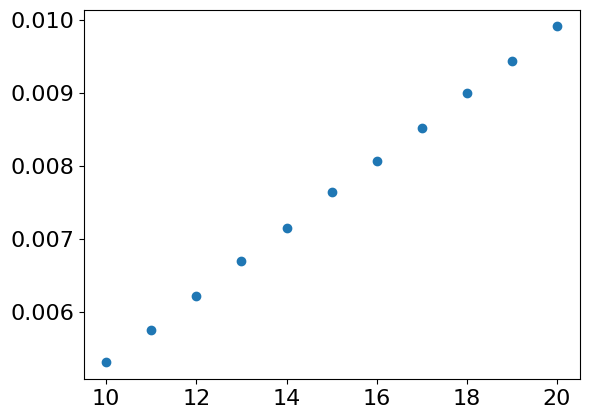

In [ ]:
# Create the plot of the pressures averaged all trials with no error bars based on the correct variables
plt.plot(V,inv_p,'o')

## 1.6 Errorbar plots

In [20]:
# @title Exercise: Create an error bar plot
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
<strong> Instructions: </strong>
    <ul>
    <li>Use the <code>plt.errorbar()</code> function to plot the best fit line with error bars.</li>
    <li>Find examples of how to use the syntax to help you create error bar plots.</li>
    <li>Look into the linestyle option if you see a line connecting your data.</li>
    </ul>
</div>

In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
  <p>
    <strong>Formatting Pointers:</strong>
    <ul>

    <li> Put a <b>r</b> before the quotes, which wraps the text and converts it to a raw string</li>
    <li>For axes labels, the $...$ notation helps with superscript/subscript for axis labels</li>
    <li>$^$ is superscript while $_$ is subscript</li>
    <li> {} are needed if there is more than one character being superscript/subscript </li>

    </ul>

See the labels below for what you should be plotting:
<ul>
<code>
<p>plt.xlabel(r'V (cm$^3$)')</p>
<p>plt.ylabel(r'1/P (kPa$^{-1}$)')</p>
</code>
</ul>

</div>


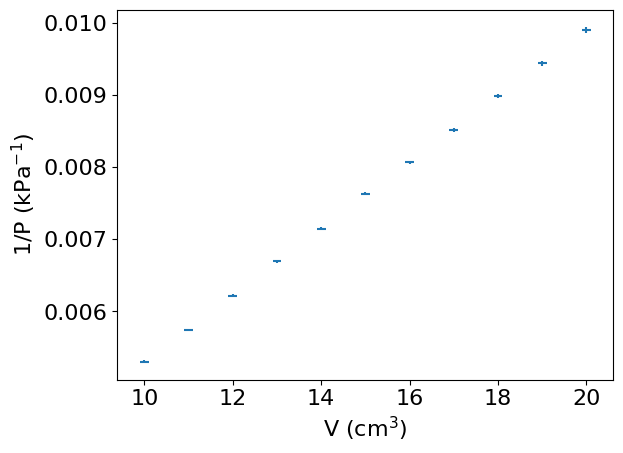

In [ ]:
# Create a linear space for volume np.linspace(start, end, number of points)
V = np.linspace(20,10,11)

# Use the slope and intercept to linearly transform x to y
plt.errorbar(V,inv_p,xerr=0.1,yerr=inv_p_95CI,linestyle='none')
plt.xlabel(r'V (cm$^3$)')
plt.ylabel(r'1/P (kPa$^{-1}$)')
plt.show()

In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
  <p>
    <strong>Need help?</strong>
    <p> There are built-in help tools that pulls up the documentation if you type a question mark after the main text. </p>
      For example, copy
<code>
plt.errorbar?
</code>

into a cell to get the help menu for plt.errorbar. This is the same as looking at matplotlib documentation.
</p>
</div>

## 1.7 Graphical Error

<div>
  <center> <img height="400" src="https://github.com/prajay-patel/CHE-3131/blob/main/Rotation-1-Treatment-of-Data/Figures/GraphicalError.png?raw=True"> </center>
</div>

A simple way to estimate uncertainty from a graph is to draw an "error box" around each data point $(x_i, y_i)$. This box is centered on the point and has a width of $\Delta_{95\%}x$ and a height of $\Delta_{95\%}y$. The idea is that the true value of the point is likely somewhere inside the box, while values outside the box are unlikely to be correct.

To visualize graphical error, we are going to fill the space in between the red and blue lines with

```python
plt.fill_between(x, y1, y2, color='grey', alpha=0.1)
```

Change the color and transparency (alpha value) as needed for aesthetics.

In [ ]:
# @title Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
    <strong>Python Negative Indexing:</strong>
    <p>
        In Python, we can count backwards from the end of the list by using negative numbers.
        Therefore, an alternative way to find the volume at the end of a list/array is:
    </p>
    <pre>
    <code>volume = np.array([20, 19, 18, ..., 10]) </code>
    volume[-1]
    Output: 10
    </pre>
</div>


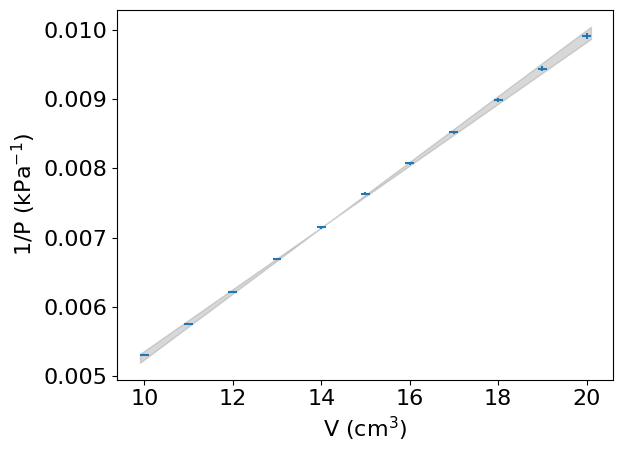

In [ ]:
# Define the x and y points for the four coordinates
# These are for the smallest volume
xmin1=V[-1]-0.1 #Students can also use 10-0.1 instead
xmax1=V[-1]+0.1 #Students can also use 10+0.1 instead
ymin1=inv_p[-1]-inv_p_95CI[-1]
ymax1=inv_p[-1]+inv_p_95CI[-1]

#These are for the largest volume
xmin2=V[0]-0.1
xmax2=V[0]+0.1
ymin2=inv_p[0]-inv_p_95CI[0]
ymax2=inv_p[0]+inv_p_95CI[0]

# Compute the two best fit lines (red and blue lines). Store these as new variables
line1 = scipy.stats.linregress([xmax1,xmin2],[ymin1,ymax2])
line2 = scipy.stats.linregress([xmin1,xmax2],[ymax1,ymin2])

# Use np.linspace(x_begin, x_end, 100) to create a list of 100 x values to plot between x_begin and x_end
V_list=np.linspace(xmin1,xmax2,100)

# Calculate the y values using V_list and your new best fit parameters. Store these as new variables.
# These lines will represent the red and blue lines as seen above.
Y1 = line1.slope*V_list+line1.intercept
Y2 = line2.slope*V_list+line2.intercept

# Plot the resulting figure using plt.fill_between()
# Include the errorbar plot as a base
fig = plt.figure()

plt.errorbar(V,inv_p,xerr=0.1,yerr=inv_p_95CI,linestyle='none')
#plt.plot(V_list,Y1,color='red',lw=0.5)
#plt.plot(V_list,Y2,color='blue',lw=0.5)
plt.fill_between(V_list,Y1,Y2, color='grey', alpha=0.3,interpolate=True)
plt.xlabel(r'V (cm$^3$)')
plt.ylabel(r'1/P (kPa$^{-1}$)')
#plt.xlim(18.5,20.5)
#plt.ylim(0.009,0.011)
plt.show()


In [ ]:
# Graphical Error determined by difference of slopes and intercepts
graph_deltab=np.abs(line1.intercept-line2.intercept)
graph_deltam=np.abs(line1.slope-line2.slope)

print('Best Fit Slope with Best Fit Error: (', '%0.2f'%(BF_slope/1e-4),'±','%0.2f'%(2*BF_slope_stderr/1e-4),') e-4')
print('Best Fit Slope with Graphical Error: (', '%0.2f'%(BF_slope/1e-4),'±','%0.2f'%(graph_deltam/1e-4),') e-4')
print('Best Fit Intercept with Graphical Error: (', '%0.2f'%(BF_intercept/1e-4),'±','%0.2f'%(2*BF_intercept_stderr/1e-4),') e-4')
print('Best Fit Intercept with Graphical Error: (', '%0.2f'%(BF_intercept/1e-4),'±','%0.2f'%(graph_deltab/1e-4),') e-4')

Best Fit Slope with Best Fit Error: ( 4.61 ± 0.02 ) e-4
Best Fit Slope with Graphical Error: ( 4.61 ± 0.30 ) e-4
Best Fit Intercept with Graphical Error: ( 6.97 ± 0.36 ) e-4
Best Fit Intercept with Graphical Error: ( 6.97 ± 4.21 ) e-4


## 1.8 Calculate V$_\text{fixed}$

<div>
  <center> <img height="300" src="https://github.com/prajay-patel/CHE-3131/blob/main/Rotation-1-Treatment-of-Data/Figures/Syringe_Vfixed.png?raw=true"> </center>
</div>

If we consider that the experimental volume is actually $V_\text{syringe}$ + $V_\text{fixed}$, and that the system obeys the ideal gas law, then the following derivation may be used to estimate $V_\text{fixed}$ from the data. $V_\text{fixed}$ is the fixed volume of the tubing that connects the syringe to the pressure sensor.
$$ p\times (V_\text{syringe} + V_\text{fixed}) = nRT $$
$$\dfrac{1}{p} = \dfrac{1}{nRT} (V_\text{syringe} + V_\text{fixed})$$
$$\dfrac{1}{p} = \dfrac{1}{nRT}\times (V_\text{syringe}) + \dfrac{V_\text{fixed}}{nRT}$$


<font color='red'>Note for instructors: For the sample data, the approximate value of $V_\text{fixed}$ is $1.47$ $\text{cm}^{3}$ based on length measurements of the tubing.</font>

<font color='red'>$V_\text{fixed}$ is calculated as the $\dfrac{intercept}{slope}=\dfrac{b}{m}$. Therefore, using the differential method for uncertainty, $$\Delta_{95\%}V=\sqrt{\bigg(\dfrac{\partial V}{\partial b}*\Delta b\bigg)^2+\bigg(\dfrac{\partial V}{\partial m}*\Delta m\bigg)^2}=\sqrt{\bigg(\dfrac{1}{m}*\Delta b\bigg)^2+\bigg(\dfrac{-b}{m^2}*\Delta m\bigg)^2}$$

The equilvalent algebraic uncertainty formula is $$\Delta_{95\%}V=V*\sqrt{\bigg(\dfrac{\Delta b}{b}\bigg)^2+\bigg(\dfrac{\Delta m}{m}\bigg)^2}$$</font>

```python
# The following function can be used for uncertainty calculations for V_fixed
def DeltaV(m,b,dm,db):
    return np.sqrt((1/m*db)**2+(-b*dm/m**2)**2)
```

In [ ]:
# @title **Question 1**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">

    <p>From the information above, how will we calculate \( V_\text{fixed} \)? Provide your answer by writing the appropriate code. </p>
</div>


In [ ]:
# Calculate V_fixed using the results of the best fit lines
Vfixed_best=BF_intercept/BF_slope
Vfixed_best_err=np.sqrt((BF_intercept_stderr/BF_intercept)**2+(BF_slope_stderr/BF_slope)**2)*Vfixed_best #algebraic method

print('V_fixed using best fit line:', '%0.2f'%Vfixed_best,'±','%0.2f'%Vfixed_best_err)

V_fixed using best fit line: 1.51 ± 0.04


In [ ]:
# Calculate V_fixed using the results of the graphical error determination
graph_deltab=np.abs(line1.intercept-line2.intercept)
graph_deltam=np.abs(line1.slope-line2.slope)

def DeltaV(m,b,dm,db):
    return np.sqrt((1/m*db)**2+(-b*dm/m**2)**2)

Vfixed_graph_err=DeltaV(BF_slope,BF_intercept,graph_deltam,graph_deltab)

print('V_fixed using best fit line:', '%0.1f'%Vfixed_best,'±','%0.1f'%Vfixed_graph_err)

V_fixed using best fit line: 1.5 ± 0.9


# Part 2. Monte Carlo Sampling


In [ ]:
# @title Overview
%%html
<style>
div.info {
    color: #0056b3;
    background-color: #d9edf7;
    border-left: 5px solid #31708f;
    padding: 0.5em;
    font-size: 1.25em; /* A little larger the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.info ul {
    margin: 0.5em 0; /* Space around the list */
}
div.info li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="info">
    <strong>Questions:</strong>
    <ul>
        <li>How do measurement uncertainties influence the distribution of best-fit lines?</li>
        <li>How well does Monte Carlo sampling effectively approximate the error in the slope and intercept?</li>
        <li>How do I choose and create the correct plot?</li>
        <li>What are different ways to represent experimental uncertainty?</li>
    </ul>

    <strong>Objectives:</strong>
    <ul>
        <li>Perform Monte Carlo sampling of error uncertainty.</li>
    </ul>
</div>

**Monte Carlo** algorithms are a class of computational methods that use repeated random sampling to obtain numerical results. These methods are especially useful for solving problems that are difficult or impossible to address analytically, such as evaluating multi-dimensional integrals, modeling uncertainty, or simulating physical systems with complex behavior. By generating a large number of random inputs, Monte Carlo simulations can be used to approximate outcomes, calculate probabilities, or explore the statistical properties of a system.

## 2.1 Demonstration

In [ ]:
# @title Exercise: Estimate $\pi$
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
    <p>Run the code cell below to estimate \( \pi \) using a Monte Carlo sampling of the ratio
      between the number of points that lie within a circle and within a square of unit distance (\(r=1\))
    </p>
</div>


For a distance $r$, since
$$A_{circle}=\pi r^2$$
$$A_{square} = 4r^2$$

then,
$$ 4 * \dfrac{A_{circle}}{A_{square}} = 4 * \dfrac{\pi r^2}{4r^2} = \pi $$

  0%|          | 0/7 [00:00<?, ?it/s]

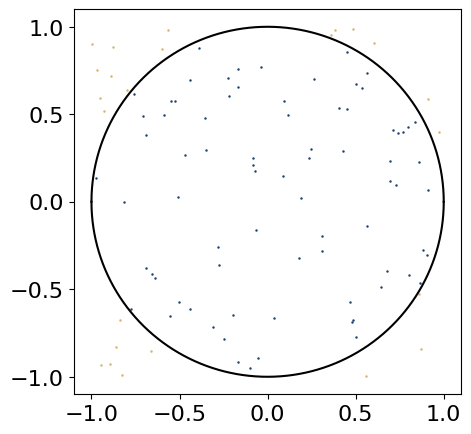

Estimate of pi using 101 points: 3.049505
Error Estimate of pi using 101 points: 0.092088


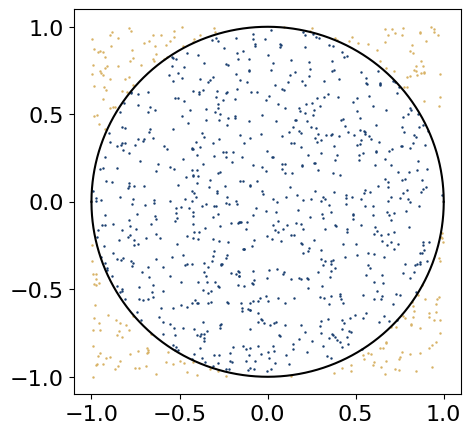

Estimate of pi using 1001 points: 3.104895
Error Estimate of pi using 1001 points: 0.036698


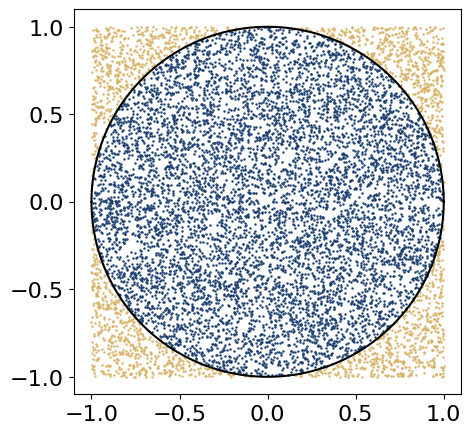

Estimate of pi using 10001 points: 3.132087
Error Estimate of pi using 10001 points: 0.009506


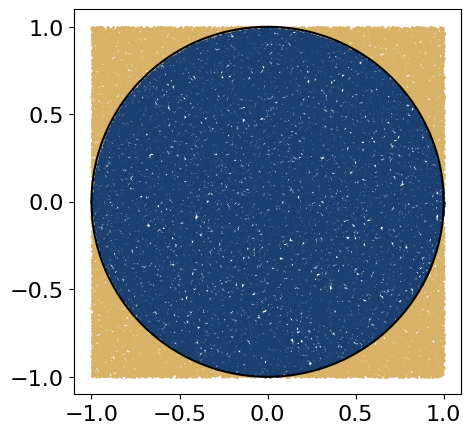

Estimate of pi using 100001 points: 3.141689
Error Estimate of pi using 100001 points: 0.000096


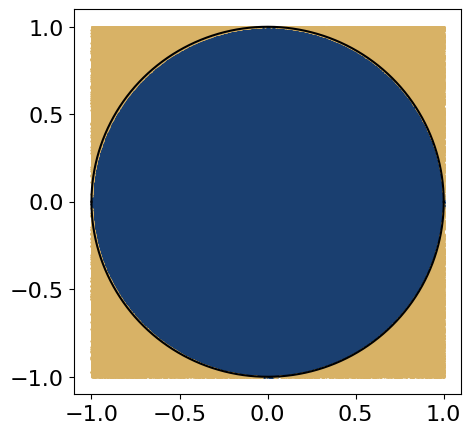

Estimate of pi using 1000001 points: 3.141509
Error Estimate of pi using 1000001 points: 0.000084


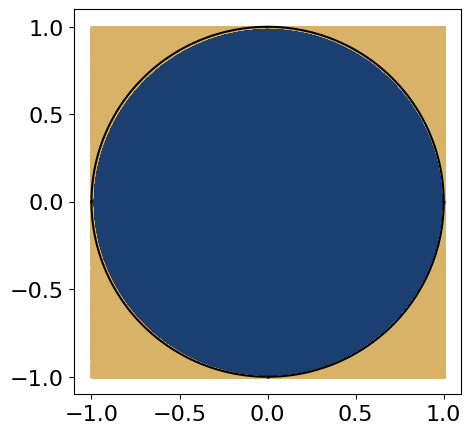

Estimate of pi using 10000001 points: 3.140966
Error Estimate of pi using 10000001 points: 0.000626


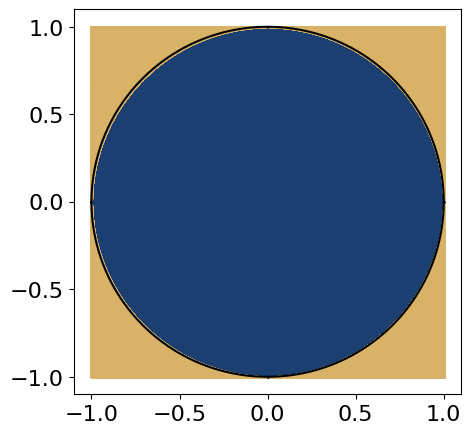

Estimate of pi using 20000001 points: 3.141108
Error Estimate of pi using 20000001 points: 0.000485


In [ ]:
# Define the number of points in a circle and square
circle_points = 0
square_points = 0

# Define the intervals
INTERVAL=[1e2+1, 1e3+1, 1e4+1, 1e5+1, 1e6+1, 1e7+1, 2e7+1]

# Drawing the circle
Xspace = np.linspace(-1,1,20001)
Yspace = np.sqrt(1-Xspace**2)

# Run a loop over all possible values
for i in trange(len(INTERVAL)):
    #Generate the number of sampling points
    rand_x = np.random.uniform(-1,1,int(INTERVAL[i]))
    rand_y = np.random.uniform(-1,1,int(INTERVAL[i]))

    # Calculate the distance of (x,y) to origin
    origin_dist = rand_x**2 + rand_y**2

    # Checking if (x,y) lies within the circle using the np.where() function, which returns elements
    cond = np.where(origin_dist<=1)
    cond2= np.array(sorted(list(set(np.arange(INTERVAL[i],dtype=int))-set(cond[0]))))

    # Computing the number of points inside the circle
    circle_points = len(cond[0])

    #Computing the number of points inside the square (includes inside the circle) -- all the points
    square_points = INTERVAL[i]

    # Plot the circle points and square points
    fig = plt.figure(figsize=(5,5))
    plt.plot(rand_x[cond],rand_y[cond],'o',markersize=0.75,color='#1A3F70')
    plt.plot(rand_x[cond2],rand_y[cond2],'o',markersize=0.75,color='#D8B266')
    plt.plot(Xspace,Yspace,'k')
    plt.plot(Xspace,-Yspace,'k')
    plt.show()

    # Estimate pi from Monte Carlo simulations
    pi_est = 4 * circle_points/square_points
    print('Estimate of pi using '+str(int(INTERVAL[i]))+' points:','%0.6f'%pi_est)
    error=np.abs(np.pi-pi_est)
    print('Error Estimate of pi using '+str(int(INTERVAL[i]))+' points:','%0.6f'%error)


In [ ]:
# @title **Question 2**
%%html
<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">

    <p>Discuss as a group what you happened in this demonstration.
      Include a summary of your discussion below. You do not have to provide a line-by-line syntax breakdown but
        enough of an explanation to show you generally understood how Monte Carlo sampling works.</p>
</div>


**Answer**

This code cell demonstrates Monte Carlo sampling to estimate the value of $\pi$. Here's a breakdown generated by Gemini (<font color=red>I would not expect students to provide this level of detail as beginners, this is for instructor purposes to judge student responses accordingly</font>):

* **Initialization:** Sets circle_points and square_points to 0 and defines a list of INTERVAL values for the number of random points to generate. It also generates points for drawing a circle for visualization.
* **Looping through intervals:** The code iterates through each value in the INTERVAL list.
* **Generating random points:** Inside the loop, it generates random x and y coordinates within the range of -1 to 1 using np.random.uniform().
* **Calculating distance:** It calculates the squared distance of each point from the origin (rand_x\*\*2 + rand_y\*\*2).
Checking if points are inside the circle: It uses np.where() to find the indices of points whose squared distance from the origin is less than or equal to 1 (meaning they are inside or on the circle with radius 1).
* **Counting points:** It counts the number of points inside the circle and the total number of points (which is the size of the interval).
* **Plotting:** It creates a scatter plot of the generated points, coloring points inside the circle blue and points outside orange. It also plots the outline of the circle.
* **Estimating $\pi$:** It estimates $\pi$ using the formula $4 \times \frac{\text{points inside circle}}{\text{total points}}$.
* **Printing results:** It prints the estimated value of $\pi$ and the error compared to the actual value of $\pi$ for each interval size.

The code shows how the estimate of $\pi$ gets closer to the actual value as the number of random points increases, illustrating the power of Monte Carlo methods for approximation.

**Sample student response**

This code estimates $\pi$ using Monte Carlo sampling with an increasing number of points. The for loop loops over seven different numbers of points. The code calculates if the coordinate lies within the circle or not. It counts the number of points inside the circle over the total number of points and then multiplies by 4 to approximate $\pi$. As the number of points increase, the 4 times the ratio of points in the circle over the total number of points gets closer to $\pi$.

## 2.2 Now it's your turn

In [ ]:
# @title Exercise: Estimate error using Monte Carlo
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">

    <strong>Objectives:</strong>
    <ul>
        <li>Grab your data values and assign them to the chosen variable names.</li>
        <li>Compute 25000, 50000, or 100000 best fit slopes and intercepts.</li>
        <li>Run the code to perform Monte Carlo sampling of your error estimates.</li>
    </ul>
</div>


In [ ]:
# Include the combined array for reciprocal pressure
DATAmean=inv_p

# Include the value of student t used
t_value=tValue

# Calculate the 95% confidence interval (tValue*std)
DATAstd=inv_p_95CI

# Array of volumes
V1=V

# Use the best fit parameters as the base line
best_fit_MC=scipy.stats.linregress(V1,DATAmean)

In [ ]:
# @title Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
    <strong>Note:</strong>
    <p>
        In your lab report, you will be responsible for interpreting the functionality of this Monte Carlo code.
    </p>
    <p>
        Once this code is finished, copy lines of the code you are curious about
        and run them in separate cells below.
    </p>
</div>


In [ ]:
#Choose the number of best fit lines to compute
points=50000

#Leave these as empty lists
stats=[]
data_pts=[]

# Generates the same random numbers for reproducibility using a random seed (any integer).
np.random.seed(10)

# Uses a progress bar (tqdm) to show how calculation is proceeding
with tqdm(total= points, desc='Calculating Best Fit Lines') as pbar:

    for i in range(points):

        # What do you think this will do?
        V_mc = V1+np.random.normal(0,0.05,11)

        # What will this line do?
        invP_mc = np.array(DATAmean+np.random.normal(loc=0, scale=DATAstd/tValue, size=(11)))

        # Do you remember what this does?
        result = scipy.stats.linregress(V_mc, invP_mc)
        tValue = tinv(0.05, len(V_mc)-2)

        m = result.slope
        m95 = tValue*result.stderr
        b = result.intercept
        b95 = tValue*result.intercept_stderr

        # Append all your data to a spreadsheet like document
        data_pts.append([V_mc,invP_mc])
        stats.append([m, m95, b, b95])

        # Updates the progress bar
        pbar.update(1)

# Export the results into a csv file
pd.DataFrame(stats).to_csv('MonteCarlo_Data.csv')

Calculating Best Fit Lines:   0%|          | 0/50000 [00:00<?, ?it/s]

In [ ]:
# Practice cell to run individual aspects of this Monte Carlo code





In [ ]:
# @title Note
%%html
<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
    <strong>Note:</strong>
    <p>
        Now that the Monte Carlo data has been generated, download the csv file.
        Then, you can just import the data as seen in the cell below rather than rerunning the Monte Carlo code again.
    </p>
</div>

In [ ]:
# Import your newly created Monte Carlo data as the variable stats. Use index_col=0.
stats=pd.read_csv('MonteCarlo_SampleData.csv',index_col=0)

# This changes the columns of the dataframe (leave as-is)
MC_stats_df=pd.DataFrame(stats)
MC_stats_df.columns=['Slope','Slope Error','Intercept','Intercept Error']
MC_stats_df

,Slope,Slope Error,Intercept,Intercept Error
0,0.000462,0.000006,0.000674,0.000094
1,0.000458,0.000003,0.000730,0.000050
2,0.000465,0.000004,0.000633,0.000061
3,0.000463,0.000007,0.000663,0.000100
4,0.000460,0.000007,0.000704,0.000109
...,...,...,...,...
49995,0.000460,0.000007,0.000711,0.000115
49996,0.000459,0.000006,0.000709,0.000086
49997,0.000457,0.000005,0.000749,0.000081
49998,0.000461,0.000007,0.000701,0.000101


In [ ]:
tValue2 = tinv(0.05, len(MC_stats_df)-2)

Here are some recommended settings for plotting the results of sampling numerous slopes and intercecpts.

```python
plt.ticklabel_format(axis='both', style='sci', scilimits=(-4,4))
plt.xlabel(r'Slopes (kPa$^{-1}$ cm$^{-3}$)')
plt.ylabel(r'Intercepts (kPa$^{-1}$)')
```

In [ ]:
# @title Exercise: Create the scatter plot
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>
<div class="orange-alert">
    <strong>Instructions:</strong>
    <p>
      <ul>
        <li>Plot the slopes vs the intercepts from the Monte Carlo data as a scatter plot</li>
        <li>Include your best fit slope and intercept as a single dot of a different color</li>
        <li>Include the graphical error slope and intercept as single dots of a different color</li>
        <li>Include a legend</li>
      </ul>
    </p>
</div>

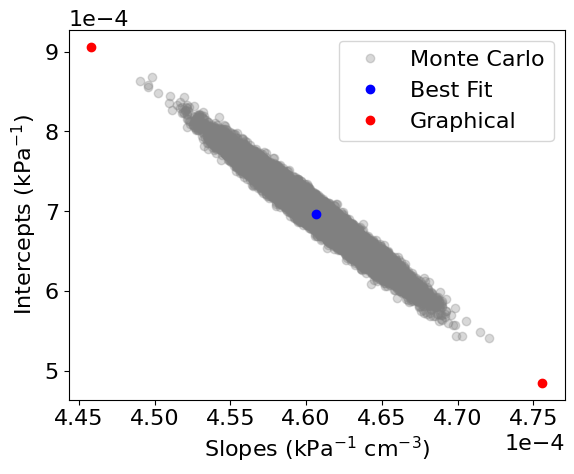

In [ ]:
# Include your code here for the scatter plot of slopes and intercepts

# Include the Monte Carlo slopes and intercepts
plt.plot(MC_stats_df['Slope'],MC_stats_df['Intercept'],'o',color='grey',\
         alpha=0.3,label='Monte Carlo')

# Include separate points for the best fit slope and intercept
plt.plot(best_fit.slope, best_fit.intercept,'bo',label='Best Fit')

# Include separate dots for the graphical error slope/intecept combinations
plt.plot(line1.slope,line1.intercept,'ro',label='Graphical')
plt.plot(line2.slope,line2.intercept,'ro')

# The code for formatting the plot
plt.ticklabel_format(axis='both', style='sci', scilimits=(-4,4))
plt.xlabel(r'Slopes (kPa$^{-1}$ cm$^{-3}$)')
plt.ylabel(r'Intercepts (kPa$^{-1}$)')

# Include the legend
plt.legend(loc=0)
plt.show()

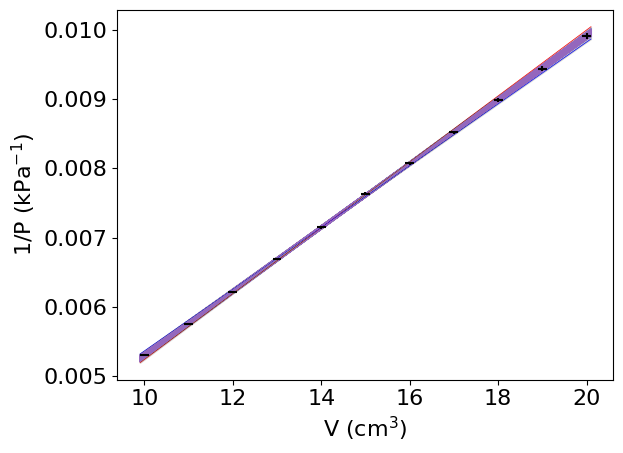

In [ ]:
# Alternative version using the plt.fill_between graph
# Note that this will take much longer to render because it is plotting 50K best fit lines

# To help speed up the rendering, the amount of points in the linear lines are reduced
V_list_abbr=np.linspace(xmin1,xmax2,5)
Y1_abbr = line1.slope*V_list_abbr+line1.intercept
Y2_abbr = line2.slope*V_list_abbr+line2.intercept

fig = plt.figure()


plt.plot(V_list_abbr,Y1_abbr,color='red',lw=0.5)
plt.plot(V_list_abbr,Y2_abbr,color='blue',lw=0.5)
plt.fill_between(V_list_abbr,Y1_abbr,Y2_abbr, color='grey', alpha=0.3,interpolate=True)
for i in range(len(MC_stats_df)):
  plt.plot(V_list_abbr,MC_stats_df['Slope'][i]*V_list_abbr+MC_stats_df['Intercept'][i], color='C4', alpha=0.005)

plt.errorbar(V,inv_p,xerr=0.1,yerr=inv_p_95CI,linestyle='none',ecolor='k')

plt.xlabel(r'V (cm$^3$)')
plt.ylabel(r'1/P (kPa$^{-1}$)')
#plt.xlim(17.8,20.2)
#plt.ylim(0.0085,0.0101)
plt.show()

In [ ]:
# Practice cells



## 2.3 Calculate V$_\text{fixed}$ using Monte Carlo

In [ ]:
Vfixed_mc=MC_stats_df['Intercept']/MC_stats_df['Slope']
Vfixed_mc_unc=(MC_stats_df['Intercept Error']/MC_stats_df['Intercept']+MC_stats_df['Slope Error']/MC_stats_df['Slope'])*Vfixed_mc

print('V_fixed using Monte Carlo','%0.2f'%Vfixed_mc.mean(),'±','%0.2f'%(Vfixed_mc_unc).mean())

V_fixed using Monte Carlo 1.52 ± 0.22


In [ ]:
# @title **Question 3**
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
</head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
</style>

<div class="gold-note">
  <ul>
    <li>What do you think the Monte Carlo
      data is showing in terms of modeling uncertainty?</li>
    <li>What are the statistics for the predicted \(V_\text{fixed} \)
      using the Monte Carlo generated slopes and intercepts?</li>
</div>


-- **Put your immediate thoughts and observations here**--
Student's full answer will be in their lab report.

This code demonstrates how Monte Carlo fits within error estimation.

In [ ]:
# @title Key Points
%%html
<style>
div.green-note {
    color: #155724; /* Dark green for text */
    background-color: #d4edda; /* Light green background */
    border-left: 5px solid #28a745; /* Bright green border */
    padding: 0.5em;
    font-size: 1.25em; /* Consistent with text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean and modern font */
}
div.green-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.green-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="green-note">
    <strong>Key Points:</strong>
    <ul>
        <li><code>axis=0</code> computes down the column</li>
        <li>Differentiate between best fit, graphical, and Monte Carlo
          methods for error estimation</li>
        <li>Visualize multiple types of plots in <code>matplotlib</code> with legends</li>
        <li>Implement <code>scipy.stats.linregress()</code> for linear regression</li>
        <li>Discuss Monte Carlo sampling in context of experimental error</li>
        <li>Calculate propagation of errors efficiently</li>
    </ul>
</div>
